Ranking the host galaxy of GW170817 with preliminary LALInference skymap.

The code was written by Mária Pálfi (marika97@student.elte.hu).

In [1]:
# importing useful packages
import pandas as pd
import numpy as np 
from scipy.stats import norm
import healpy as hp

from ligo.skymap.io import read_sky_map
from astropy import units as u

import astropy_healpix as ah

/home/marika/.local/lib/python3.10/site-packages/ligo/lw/lsctables.py:89: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [2]:
# Read data
hosts = pd.read_csv('../total_host_list_pre.csv')

In [3]:
print( 'Number of galaxies inside the 90% localisation volume:',  len( hosts ) )

Number of galaxies inside the 90% localisation volume: 56


In [4]:
# download preliminary LALInference skymap
url = "https://dcc.ligo.org/public/0146/G1701985/001/preliminary-LALInference.fits.gz"
skymap = read_sky_map(url, moc=True)

Calculate useful things

In [5]:
uniq = skymap['UNIQ']
prob = skymap['PROBDENSITY']
distnorm = skymap['DISTNORM']
distmu = skymap['DISTMU']
distsigma = skymap['DISTSIGMA']

level, ipix = ah.uniq_to_level_ipix(uniq)
nside = ah.level_to_nside(level)
pixarea = hp.nside2pixarea(nside)

Define function for ranking based on localisation:

In [6]:
def dp_dV_calc(hosts, n, dp_dV, nside, ipix, prob, distmu, distsigma, distnorm, pixarea):
    match_ipix = ah.lonlat_to_healpix( hosts.iloc[n]['_RAJ2000']*u.deg, 
                                      hosts.iloc[n]['_DEJ2000'] *u.deg,
                                      nside, order = 'nested'  )
    i = np.flatnonzero(ipix == match_ipix)[0]
    dp_dV.append( prob[i] * distnorm[i] * 
                     norm( distmu[i], distsigma[i] ).pdf(hosts.iloc[n]['dL']) 
                     / pixarea[i] )

Index of the host galaxy:

In [7]:
print(hosts.index[hosts.GWGC == 'NGC4993'][0])

2


**Ranking by localization probability**

In [8]:
dp_dV = []
for n in range(len(hosts)): dp_dV_calc(hosts, n, dp_dV, nside, ipix,
                                       prob, distmu, distsigma, distnorm, pixarea)
hosts['dp_dV'] = dp_dV
s_dp_dV = hosts.sort_values( by = ['dp_dV'] , axis = 0, ascending = False ).index

The ranked list of indices:

In [9]:
s_dp_dV

Index([11, 22, 18,  3, 41, 52, 31, 19,  5, 13, 14, 27, 50, 36, 25, 17, 40,  1,
       42,  8, 21,  7, 10, 23, 48, 24,  2,  9, 54, 30, 37, 29,  6, 53, 28, 46,
       49, 44,  4, 12, 20, 15, 35, 33, 45, 47, 26, 38, 39, 55, 43, 51, 16,  0,
       32, 34],
      dtype='int64')

What is the rank of NGC4993 based on localisation alone?

In [10]:
def rank(arr):
    for i in arr:
        if arr[i] == hosts.index[hosts.GWGC == 'NGC4993'][0]:
            print(i+1)

In [11]:
rank( s_dp_dV )

27


# With stellar mass

In [12]:
# read stellar mass data
data = pd.read_csv( 'total_sm.txt', delimiter = '\t', low_memory=False )

In [13]:
# read weights from Artale
prob_M_BBH = pd.read_csv('../Probability_Mstar_BBH_z0p1.dat', delimiter='\t', 
                         header = 0, names = ['logMs', 'P'] )

In [14]:
# Save stellar masses 
Cluver, Jarrett, Kettlety, Cappellari = [], [], [], []
for i in hosts.GLADE_:
    if len( data[data.ID == i]['SMass_Cluver'].values ) == 0:
        Cluver.append( 0 )
    else:
        Cluver.append( data[data.ID == i]['SMass_Cluver'].values[0] )
    if len( data[data.ID == i]['SMass_Jarrett'].values ) == 0:
        Jarrett.append( 0 )
    else:
        Jarrett.append( data[data.ID == i]['SMass_Jarrett'].values[0] )
    if len( data[data.ID == i]['SMass_Kettlety'].values ) == 0:
        Kettlety.append( 0 )
    else:
        Kettlety.append( data[data.ID == i]['SMass_Kettlety'].values[0] )
    if len( data[data.ID == i]['SMass_Cappellari'].values ) == 0:
        Cappellari.append( 0 )
    else:
        Cappellari.append( data[data.ID == i]['SMass_Cappellari'].values[0] )

In [15]:
# add stellar masses to dataframe, fill nans with zeros
hosts['Cluver'] = Cluver
hosts.fillna( {'Cluver' : 0 }, inplace=True)
hosts['Kettlety'] = Kettlety
hosts.fillna( {'Kettlety' : 0 }, inplace=True)
hosts['Jarrett'] = Jarrett
hosts.fillna( {'Jarrett' : 0 }, inplace=True)
hosts['Cappellari'] = Cappellari
hosts.fillna( {'Cappellari' : 0 }, inplace=True)

In [16]:
len(hosts)

56

In [17]:
print( len(hosts[hosts.Jarrett > 0]) )
print( len(hosts[hosts.Cluver > 0]) )
print( len(hosts[hosts.Kettlety > 0]) )
print( len(hosts[hosts.Cappellari > 0]) )

48
48
48
13


(array([3., 0., 1., 0., 0., 3., 2., 0., 1., 3.]),
 array([0.00764 , 0.007996, 0.008352, 0.008708, 0.009064, 0.00942 ,
        0.009776, 0.010132, 0.010488, 0.010844, 0.0112  ]),
 <BarContainer object of 10 artists>)

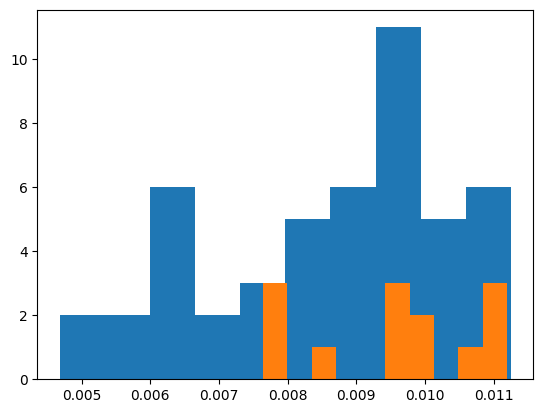

In [18]:
import matplotlib.pyplot as plt
plt.hist(hosts[hosts.Jarrett > 0].zhelio)
plt.hist(hosts[hosts.Cappellari > 0].zhelio)

(array([3., 1., 0., 0., 2., 3., 0., 0., 2., 2.]),
 array([0.00707466, 0.00747408, 0.0078735 , 0.00827291, 0.00867233,
        0.00907175, 0.00947116, 0.00987058, 0.01027   , 0.01066941,
        0.01106883]),
 <BarContainer object of 10 artists>)

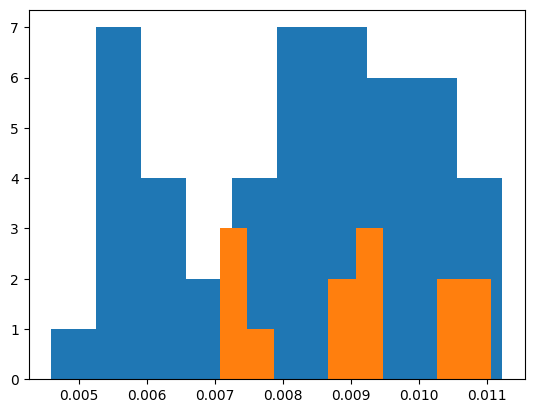

In [19]:
plt.hist(hosts[hosts.Jarrett > 0].zcmb)
plt.hist(hosts[hosts.Cappellari > 0].zcmb)

In [17]:
print(hosts.Jarrett[hosts.GWGC == 'NGC4993'])
print(hosts.Cluver[hosts.GWGC == 'NGC4993'])
print(hosts.Kettlety[hosts.GWGC == 'NGC4993'])
print(hosts.Cappellari[hosts.GWGC == 'NGC4993'])

2    2.443926e+10
Name: Jarrett, dtype: float64
2    3.957793e+10
Name: Cluver, dtype: float64
2    2.216191e+10
Name: Kettlety, dtype: float64
2    9.087011e+10
Name: Cappellari, dtype: float64


In [25]:
print(np.log10(max(hosts.Jarrett)))
print(np.log10(max(hosts.Cluver)))
print(np.log10(max(hosts.Kettlety)))
print(np.log10(max(hosts.Cappellari)))

10.600363794065501
10.808691045905501
10.542094432578752
11.296025544889147


Functions to calculate $G_\text{tot}$:

In [18]:
from scipy.interpolate import interp1d

In [19]:
def find_nearest(array, value, return_array):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return return_array[idx]

def interpolate( x, lgM, prob, kind = 'linear' ):
    interpolator = interp1d( lgM, prob, kind=kind, fill_value='extrapolate')
    P = interpolator(x)
    P[x > prob_M_BBH.logMs[23]] = prob_M_BBH.P[23]
    return P

def pM_Ducoin( hosts, M, dp_dV ):
    pM = M/np.sum(M)
    alpha = np.sum(hosts[M!=0]['dp_dV'])/np.sum(hosts[M!=0]['dp_dV']*pM[M!=0])
    hosts['dp_dV_pM'] = dp_dV/np.sum(dp_dV)*(1+alpha*pM)
    return hosts.sort_values( by = ['dp_dV_pM'] , axis = 0, ascending = False ).index

def pM_Artale( hosts, M, dp_dV ):
    prob_M_vals = []
    for i in range(len(M)):
        if M[i] != 0:
            lg_sm = np.log10(M[i])
            prob_M_vals.append( find_nearest( prob_M_BBH['logMs'], lg_sm, prob_M_BBH['P'] ) )
        else:
            prob_M_vals.append( 0 )
    prob_M_Artale = prob_M_vals/np.sum(prob_M_vals)
    hosts['prob_M_Artale'] = prob_M_Artale
    alpha = np.sum(hosts[M!=0]['dp_dV'])/np.sum(hosts[M!=0]['dp_dV']*prob_M_Artale[M!=0])
    hosts['prob_Artale'] = dp_dV/np.sum(dp_dV) * (1+alpha*hosts.prob_M_Artale)
    return hosts.sort_values( by = ['prob_Artale'] , axis = 0, ascending = False ).index

def pM_Artale_interpolate( hosts, M, dp_dV ):
    prob_M_vals = []
    for i in range(len(M)):
        if M[i] != 0:
            lg_sm = np.log10(M[i])
            prob_M_vals.append( interpolate( lg_sm, prob_M_BBH['logMs'], prob_M_BBH['P'] ) )
        else:
            prob_M_vals.append( 0 )
    #print( 'prob: ', prob_M_vals )
    prob_M_Artale = prob_M_vals/np.sum(prob_M_vals)
    hosts['prob_M_Artale'] = prob_M_Artale
    alpha = np.sum(hosts[M!=0]['dp_dV'])/np.sum(hosts[M!=0]['dp_dV']*prob_M_Artale[M!=0])
    hosts['prob_Artale'] = dp_dV/np.sum(dp_dV) * (1+alpha*hosts.prob_M_Artale)
    return hosts.sort_values( by = ['prob_Artale'] , axis = 0, ascending = False ).index

**Rank of NGC4993 with $M_\ast$ from Jarrett's method**

In [20]:
s_D_Jarrett = pM_Ducoin( hosts, hosts.Jarrett, dp_dV )
s_A_Jarrett = pM_Artale( hosts, hosts.Jarrett, dp_dV )
s_Ai_Jarrett = pM_Artale_interpolate( hosts, hosts.Jarrett, dp_dV )
rank( s_D_Jarrett )
rank( s_A_Jarrett )
rank( s_Ai_Jarrett )

16
17
16


**Rank of NGC4993 with $M_\ast$ from Cluver's method**

In [21]:
s_D_Cluver = pM_Ducoin( hosts, hosts.Cluver, dp_dV )
s_A_Cluver = pM_Artale( hosts, hosts.Cluver, dp_dV )
s_Ai_Cluver = pM_Artale_interpolate( hosts, hosts.Cluver, dp_dV )
rank( s_D_Cluver )
rank( s_A_Cluver )
rank( s_Ai_Cluver )

16
16
16


**Rank of NGC4993 with $M_\ast$ from Kettlety's method**

In [22]:
s_D_Kettlety = pM_Ducoin( hosts, hosts.Kettlety, dp_dV )
s_A_Kettlety = pM_Artale( hosts, hosts.Kettlety, dp_dV )
s_Ai_Kettlety = pM_Artale_interpolate( hosts, hosts.Kettlety, dp_dV )
rank( s_D_Kettlety )
rank( s_A_Kettlety )
rank( s_Ai_Kettlety )

16
20
18


**Rank of NGC4993 with $M_\ast$ from Cappellari's method**

In [23]:
s_D_Cappellari = pM_Ducoin( hosts, hosts.Cappellari, dp_dV )
s_A_Cappellari = pM_Artale( hosts, hosts.Cappellari, dp_dV )
s_Ai_Cappellari = pM_Artale_interpolate( hosts, hosts.Cappellari, dp_dV )
rank( s_D_Cappellari )
rank( s_A_Cappellari )
rank( s_Ai_Cappellari )

21
21
22
